# 🔬 AFETSONAR — Tanı: Öğretmen Pre-Channel'ları Kullanıyor mu?

**Calamitas AI · Teknofest 2025 · Tanı Notebook'u**

---

## 📌 Bu Notebook Ne Yapıyor?

Eğitilmiş öğretmen modelinin (`teacher_best.pth`) gerçekten **afet öncesi (pre-disaster)** görüntülerden faydalanıp faydalanmadığını test ediyor.

### Hipotez

Notebook 2'nin sonuçlarında gördük ki:
- Model binaları buluyor ✅
- Ama hasar **seviyesini** ayırt edemiyor ❌ (her şeyi yeşil/no-damage tahmin ediyor)

Bu, modelin **post-disaster'a kilitlenmiş** olabileceğine işaret ediyor — yani 6 kanaldan sadece 3'ünü (post) kullanıyor olabilir, pre'yi neredeyse hiç dinlememiş.

### Test yöntemi

Aynı val örneklerini **3 farklı şekilde** modele veriyoruz:

1. **Normal**: pre + post (gerçek çift)
2. **Pre = sıfır**: post normal, pre tamamen siyah → model pre'siz çalışıyormuş gibi
3. **Pre = post**: pre yerine post'un kopyasını ver → "değişim yok" sinyali

Sonra her birinin tahminini karşılaştırıyoruz.

### Yorumlama

| Sonuç | Anlamı | Strateji |
|---|---|---|
| 3 tahmin **birbirinden farklı** | Model pre'yi aktif kullanıyor | Hyperparameter tuning yeter (Strateji A) |
| 3 tahmin **çok benzer** | Model pre'yi neredeyse görmezden geliyor | Mimari değişiklik gerekli (Strateji B) |
| 1 ve 3 **aynı**, 2 farklı | Model "değişim sinyali" arıyor | Loss değişikliği yardım eder |

### Süre

5-10 dakika. CPU runtime'ında bile çalışır (sadece inference).

---

## 1️⃣ Kurulum

GPU runtime önerilir ama CPU da olur (sadece inference yapacağız, eğitim yok).

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
CKPT_TEACHER = os.path.join(PROJECT_ROOT, "checkpoints/teacher")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

# Sanity check
required = [SRC_DIR, CKPT_TEACHER, DATA_SPLITS]
for path in required:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Eksik: {path}\nNotebook 1 ve 2'yi çalıştırdın mı?")

best_model_path = os.path.join(CKPT_TEACHER, "teacher_best.pth")
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"teacher_best.pth bulunamadı: {best_model_path}")

print(f"✅ Drive bağlandı")
print(f"✅ teacher_best.pth bulundu")

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n⚙️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
✅ Drive bağlandı
✅ teacher_best.pth bulundu

⚙️  Device: cuda
   GPU: Tesla T4


## 2️⃣ Kütüphane Kontrolü

`transformers` ve `albumentations` kurulu mu kontrol et.

In [2]:
print("📦 Kütüphane kontrolü...")
print("=" * 50)

needed = []
for name in ["transformers", "albumentations", "segmentation_models_pytorch"]:
    try:
        mod = __import__(name)
        ver = getattr(mod, "__version__", "?")
        print(f"  ✅ {name:30s} {ver}")
    except ImportError:
        print(f"  ⏳ {name:30s} kurulacak")
        needed.append(name)

if needed:
    pkg_names = " ".join(n.replace("_", "-") for n in needed)
    print(f"\n📥 Kuruluyor: {pkg_names}")
    !pip install -q {pkg_names}

print("\n✅ Hazır")

📦 Kütüphane kontrolü...
  ✅ transformers                   5.0.0
  ✅ albumentations                 2.0.8
  ⏳ segmentation_models_pytorch    kurulacak

📥 Kuruluyor: segmentation-models-pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00

✅ Hazır


## 3️⃣ Eğitilmiş Modeli Yükle

`src/models.py`'deki `TeacherSegformer`'ı kullanıp `teacher_best.pth` ağırlıklarını yüklüyoruz.

In [3]:
import sys
sys.path.insert(0, SRC_DIR)

import importlib
import models, dataset, augmentations, utils
importlib.reload(models)
importlib.reload(dataset)
importlib.reload(augmentations)
importlib.reload(utils)

from models import TeacherSegformer
from dataset import XBDDataset
from augmentations import get_val_augmentation
from utils import DAMAGE_CMAP, denormalize

print("🏗️  Model inşa ediliyor (ağırlık yüklenecek)...")
model = TeacherSegformer(
    backbone_name="nvidia/segformer-b5-finetuned-ade-640-640",
    num_damage_classes=5,
    num_disaster_classes=5,
    pretrained=True,  # İlk önce HF'den indir, sonra üzerine kendi ağırlıklarımız
)

print(f"\n📂 Checkpoint yükleniyor: {best_model_path}")
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print(f"✅ Model yüklendi")
print(f"   Eğitilmiş epoch:    {checkpoint.get('epoch', '?')}")
print(f"   val_mIoU:           {checkpoint.get('val_miou', '?'):.4f}")
print(f"   val_mIoU_no_bg:     {checkpoint.get('val_miou_no_bg', '?'):.4f}")

🏗️  Model inşa ediliyor (ağırlık yüklenecek)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/339M [00:00<?, ?B/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b5-finetuned-ade-640-640
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([5])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([5, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



📂 Checkpoint yükleniyor: /content/drive/MyDrive/AFETSONAR/checkpoints/teacher/teacher_best.pth
✅ Model yüklendi
   Eğitilmiş epoch:    58
   val_mIoU:           0.4271
   val_mIoU_no_bg:     0.2981


## 4️⃣ Val Dataset'i Hazırla

Test için validation setinden örnekler çekeceğiz.

In [4]:
val_aug = get_val_augmentation(image_size=512, mode="teacher")
val_ds = XBDDataset(
    csv_path=os.path.join(DATA_SPLITS, "val.csv"),
    mode="teacher",
    augmentation=val_aug,
)
print(f"✅ Val dataset hazır: {len(val_ds)} örnek")

✅ Val dataset hazır: 420 örnek


## 5️⃣ Pre-Channel Tanı Testi

### Ne yapıyoruz?

Her örnek için 3 versiyon oluşturuyoruz:

```
v1 (normal):    image = [pre, post]      ← gerçek
v2 (no-pre):    image = [zeros, post]    ← pre tamamen siyah
v3 (pre=post):  image = [post, post]     ← pre yerine post kopyası
```

Sonra her birini modele veriyoruz, çıktıları karşılaştırıyoruz.

### Metrik

İki tahmin arasındaki **piksel uyuşma oranı** (agreement):

```
agreement(A, B) = (A == B).mean()
```

Yüksek agreement = tahminler benzer = pre kanalları önemsiz.
Düşük agreement = pre kanalları gerçekten değiştiriyor.

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.nn.functional import softmax

# Test edilecek örnek sayısı
N_SAMPLES = 8

random.seed(42)
sample_indices = random.sample(range(len(val_ds)), N_SAMPLES)

# === Yardımcı: bir image tensoru için 3 farklı tahmin yap ===
@torch.no_grad()
def predict_three_ways(image_tensor):
    # image_tensor: [6, H, W] tensor (already normalized)
    # Returns: dict with v1, v2, v3 predictions (each [H, W] long tensor)
    # v1: normal
    img_v1 = image_tensor.unsqueeze(0).to(device)

    # v2: pre kanallarını sıfırla
    img_v2 = image_tensor.clone()
    img_v2[:3] = 0.0
    img_v2 = img_v2.unsqueeze(0).to(device)

    # v3: pre yerine post kopyası
    img_v3 = image_tensor.clone()
    img_v3[:3] = image_tensor[3:].clone()
    img_v3 = img_v3.unsqueeze(0).to(device)

    # Forward (bf16 desteği varsa onu kullan)
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        amp_dtype = torch.bfloat16
    else:
        amp_dtype = torch.float16

    results = {}
    for name, img in [("v1_normal", img_v1), ("v2_no_pre", img_v2), ("v3_pre_eq_post", img_v3)]:
        if torch.cuda.is_available():
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                out = model(img)
        else:
            out = model(img)
        pred = out["damage_logits"].argmax(dim=1)[0].cpu()
        probs = softmax(out["damage_logits"].float(), dim=1)[0].cpu()
        results[name] = {"pred": pred, "probs": probs}

    return results


# === Tüm örnekler için test yap ===
print("🔬 Pre-channel tanı testi başlıyor...")
print("=" * 70)

agreement_v1_v2 = []  # normal vs no-pre
agreement_v1_v3 = []  # normal vs pre=post
agreement_v2_v3 = []  # no-pre vs pre=post

# Her örnek için detaylı sonuç
detailed_results = []

for i, idx in enumerate(sample_indices):
    sample = val_ds[idx]
    image = sample["image"]
    gt_mask = sample["mask"]

    preds = predict_three_ways(image)

    v1 = preds["v1_normal"]["pred"].numpy()
    v2 = preds["v2_no_pre"]["pred"].numpy()
    v3 = preds["v3_pre_eq_post"]["pred"].numpy()

    agree_12 = (v1 == v2).mean()
    agree_13 = (v1 == v3).mean()
    agree_23 = (v2 == v3).mean()

    agreement_v1_v2.append(agree_12)
    agreement_v1_v3.append(agree_13)
    agreement_v2_v3.append(agree_23)

    detailed_results.append({
        "idx": idx,
        "filename": sample["filename"],
        "image": image,
        "gt": gt_mask,
        "v1": v1, "v2": v2, "v3": v3,
        "agree_12": agree_12,
        "agree_13": agree_13,
        "agree_23": agree_23,
    })

    print(f"  Örnek {i+1}/{N_SAMPLES} ({sample['filename'][:35]}...):")
    print(f"    Normal vs NoPre:  {agree_12:.4f} agreement")
    print(f"    Normal vs Pre=Post: {agree_13:.4f}")
    print(f"    NoPre vs Pre=Post:  {agree_23:.4f}")

# === Özet ===
print("\n" + "=" * 70)
print("📊 ÖZET")
print("=" * 70)
mean_12 = np.mean(agreement_v1_v2)
mean_13 = np.mean(agreement_v1_v3)
mean_23 = np.mean(agreement_v2_v3)

print(f"  Normal vs NoPre:    {mean_12:.4f}  (1.0 = pre tamamen yoksayılıyor)")
print(f"  Normal vs Pre=Post: {mean_13:.4f}")
print(f"  NoPre vs Pre=Post:  {mean_23:.4f}")

print()
if mean_12 > 0.99:
    print("🚨 SONUÇ: Model pre kanallarını tamamen yoksayıyor!")
    print("   → Mimari değişikliği gerekli (Strateji B)")
elif mean_12 > 0.95:
    print("⚠️  SONUÇ: Model pre kanallarını çok az kullanıyor")
    print("   → Loss + augmentation tuning yardım edebilir, ama sınırlı")
elif mean_12 > 0.85:
    print("📊 SONUÇ: Model pre kanallarını orta düzeyde kullanıyor")
    print("   → Hyperparameter tuning yeter (Strateji A)")
else:
    print("✅ SONUÇ: Model pre kanallarını aktif kullanıyor")
    print("   → Sorun başka yerde (loss / class weights / kapasite)")

🔬 Pre-channel tanı testi başlıyor...
  Örnek 1/8 (socal-fire_00000859_post_disaster.p...):
    Normal vs NoPre:  1.0000 agreement
    Normal vs Pre=Post: 0.9995
    NoPre vs Pre=Post:  0.9995
  Örnek 2/8 (palu-tsunami_00000074_post_disaster...):
    Normal vs NoPre:  0.9122 agreement
    Normal vs Pre=Post: 0.9345
    NoPre vs Pre=Post:  0.9350
  Örnek 3/8 (midwest-flooding_00000038_post_disa...):
    Normal vs NoPre:  0.9952 agreement
    Normal vs Pre=Post: 0.9978
    NoPre vs Pre=Post:  0.9961
  Örnek 4/8 (mexico-earthquake_00000126_post_dis...):
    Normal vs NoPre:  0.9053 agreement
    Normal vs Pre=Post: 0.9008
    NoPre vs Pre=Post:  0.9445
  Örnek 5/8 (hurricane-harvey_00000514_post_disa...):
    Normal vs NoPre:  0.9721 agreement
    Normal vs Pre=Post: 0.9705
    NoPre vs Pre=Post:  0.9807
  Örnek 6/8 (hurricane-harvey_00000272_post_disa...):
    Normal vs NoPre:  0.9918 agreement
    Normal vs Pre=Post: 0.9917
    NoPre vs Pre=Post:  0.9957
  Örnek 7/8 (hurricane-florence_0

## 6️⃣ Görsel Karşılaştırma

İlk 4 örneği görsel olarak karşılaştır. Her satırda 6 panel:
1. Pre (afet öncesi)
2. Post (afet sonrası)
3. Ground Truth (gerçek mask)
4. Normal tahmin (v1)
5. Pre=zero tahmin (v2)
6. Pre=post tahmin (v3)

Eğer panel 4, 5, 6 **birbirine çok benziyorsa** → model pre'yi öğrenmemiş.

✅ Görsel kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/visualizations/pre_channel_diagnostic.png


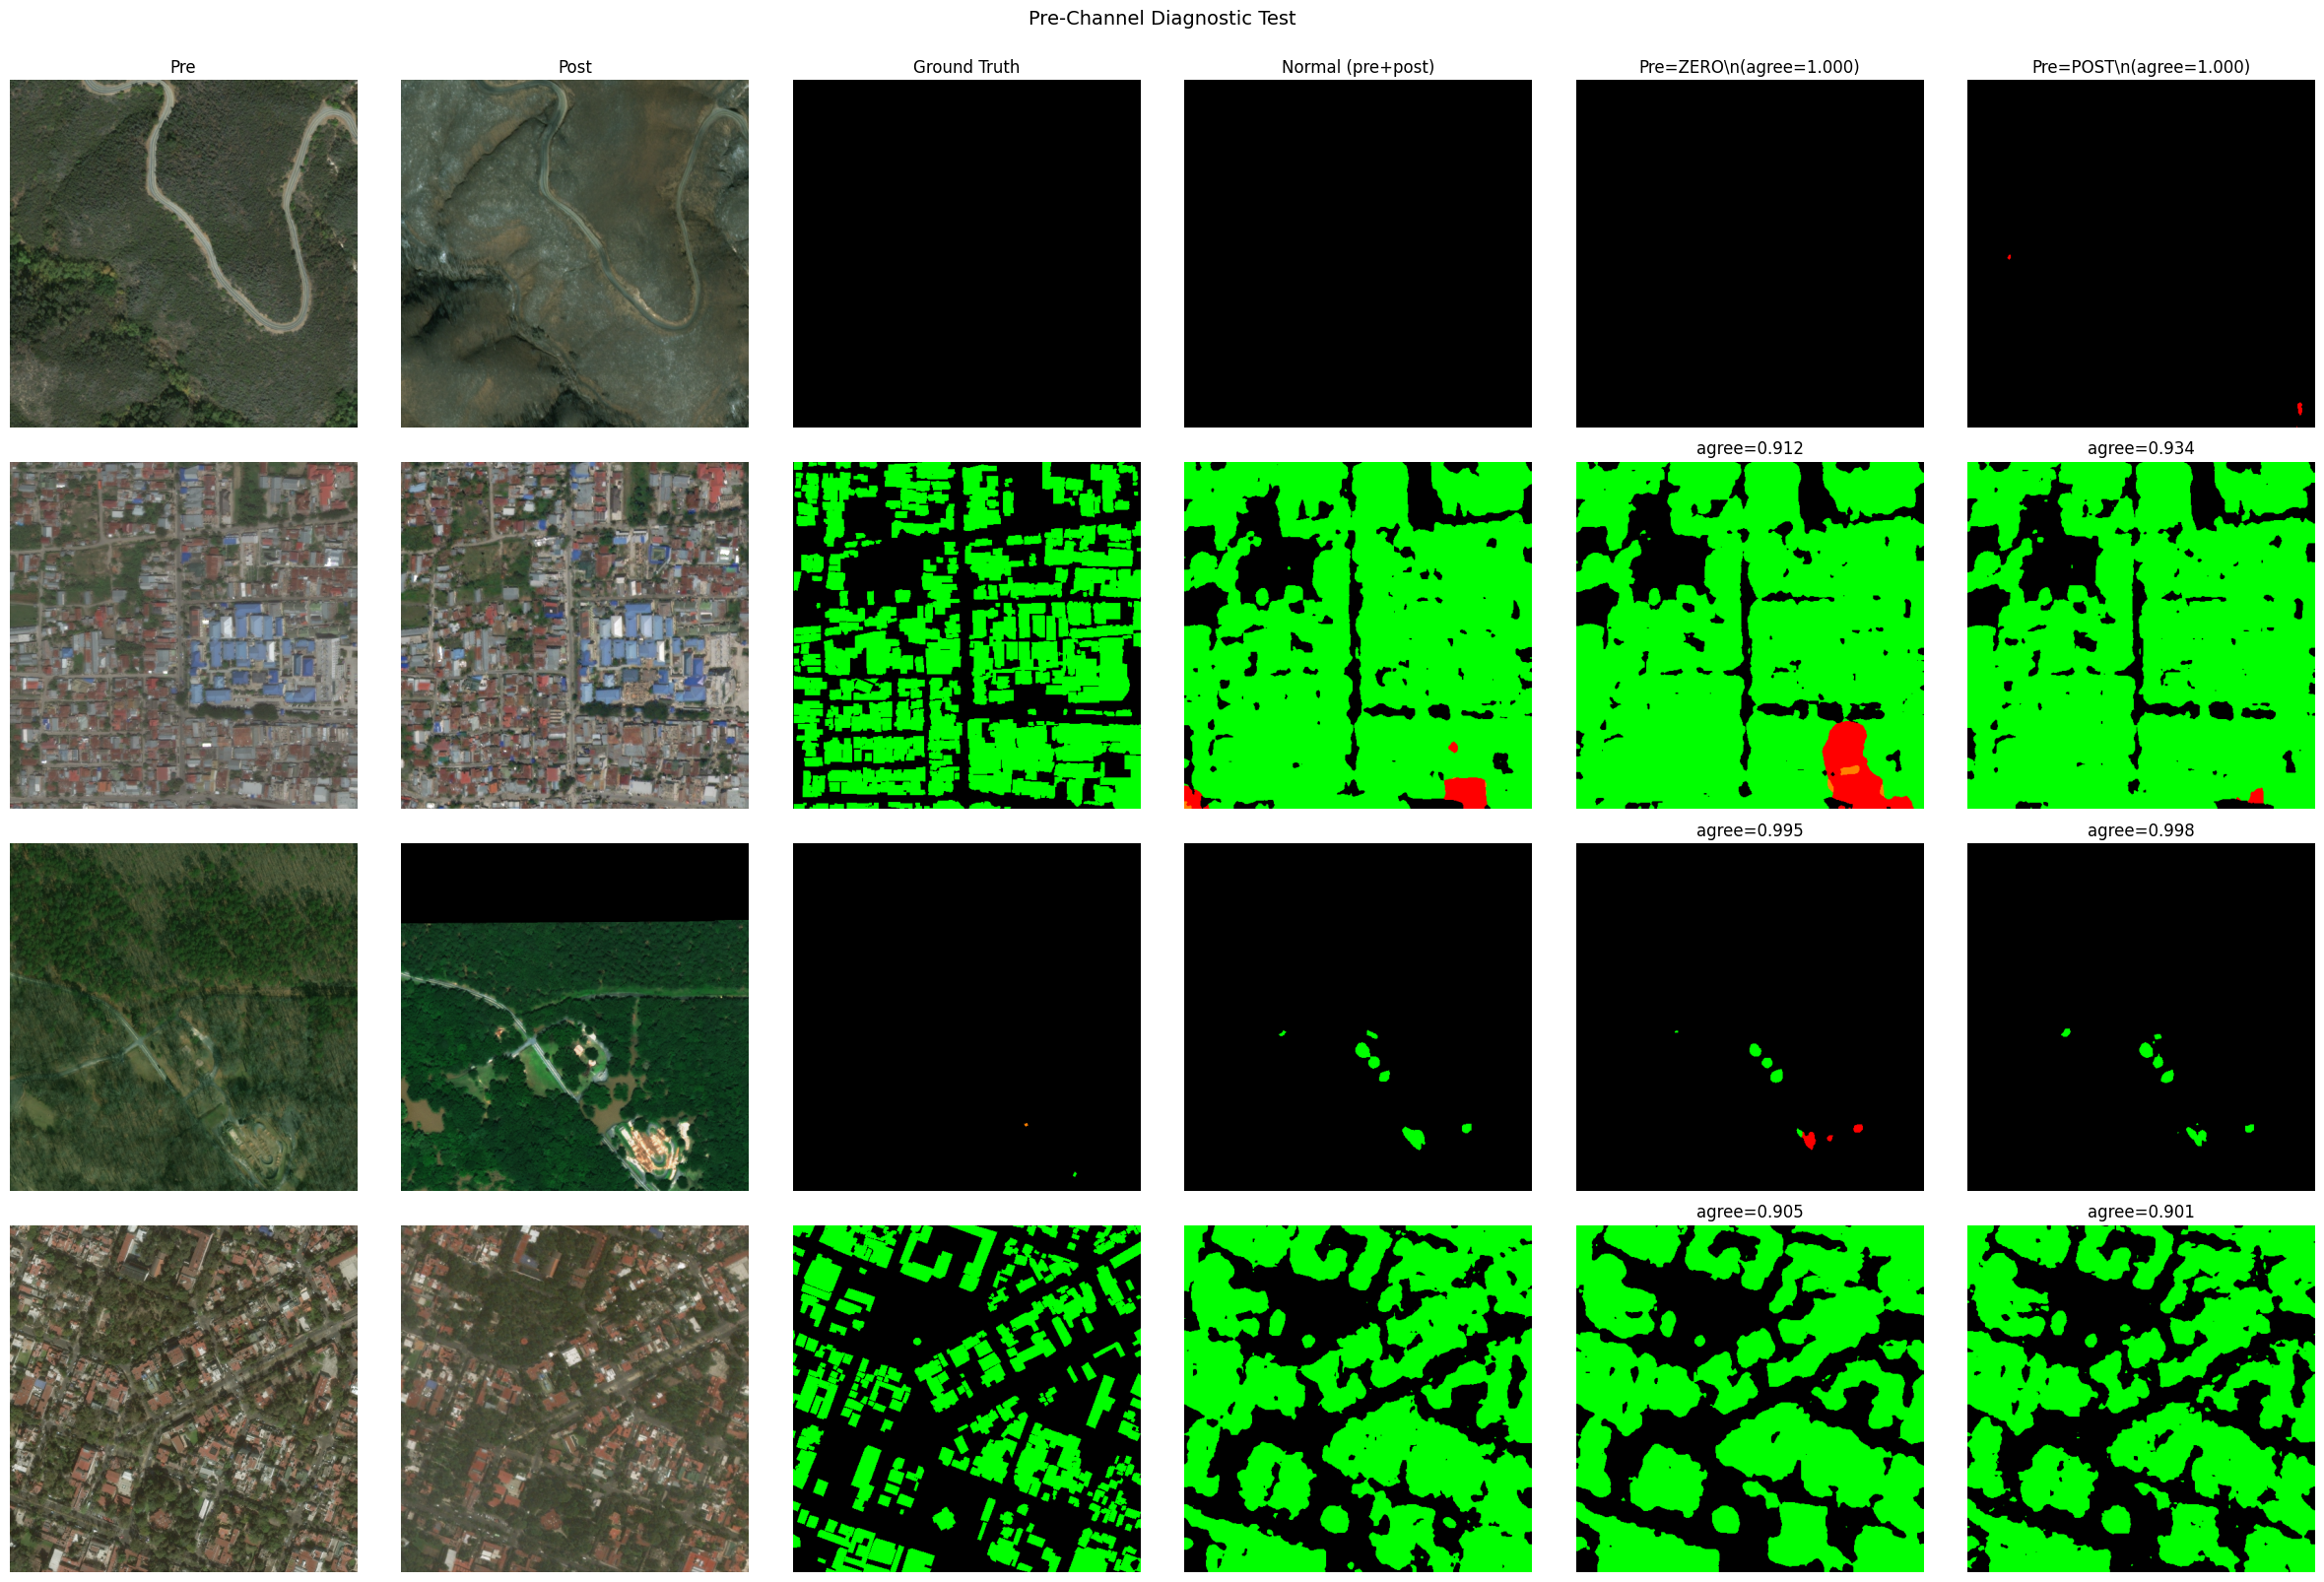

In [6]:
n_show = min(4, len(detailed_results))
fig, axes = plt.subplots(n_show, 6, figsize=(24, 4 * n_show))

if n_show == 1:
    axes = axes.reshape(1, -1)

for row, result in enumerate(detailed_results[:n_show]):
    image = result["image"]
    pre = denormalize(image[:3]).permute(1, 2, 0).numpy().clip(0, 1)
    post = denormalize(image[3:]).permute(1, 2, 0).numpy().clip(0, 1)

    axes[row, 0].imshow(pre)
    axes[row, 0].set_title("Pre" if row == 0 else "")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(post)
    axes[row, 1].set_title("Post" if row == 0 else "")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(result["gt"].numpy(), cmap=DAMAGE_CMAP, vmin=0, vmax=4)
    axes[row, 2].set_title("Ground Truth" if row == 0 else "")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(result["v1"], cmap=DAMAGE_CMAP, vmin=0, vmax=4)
    axes[row, 3].set_title("Normal (pre+post)" if row == 0 else "")
    axes[row, 3].axis("off")

    axes[row, 4].imshow(result["v2"], cmap=DAMAGE_CMAP, vmin=0, vmax=4)
    axes[row, 4].set_title(f"Pre=ZERO\\n(agree={result['agree_12']:.3f})" if row == 0 else f"agree={result['agree_12']:.3f}")
    axes[row, 4].axis("off")

    axes[row, 5].imshow(result["v3"], cmap=DAMAGE_CMAP, vmin=0, vmax=4)
    axes[row, 5].set_title(f"Pre=POST\\n(agree={result['agree_13']:.3f})" if row == 0 else f"agree={result['agree_13']:.3f}")
    axes[row, 5].axis("off")

plt.suptitle("Pre-Channel Diagnostic Test", fontsize=14, y=1.001)
plt.tight_layout()

# Drive'a kaydet
diag_path = os.path.join(OUTPUTS_VIZ, "pre_channel_diagnostic.png")
plt.savefig(diag_path, dpi=80, bbox_inches="tight")
print(f"✅ Görsel kaydedildi: {diag_path}")
plt.show()

## 7️⃣ Sınıf Dağılımı Analizi

Modelin tahminlerinde hangi sınıfları ne sıklıkla kullandığını görelim. Eğer model **her şeyi no_damage (sınıf 1)** tahmin ediyorsa, bu şüphemizi doğrular.

Plus: gerçek dağılımla karşılaştırırız.

In [7]:
print("📊 Tahmin sınıf dağılımı (val'in tamamı üzerinde değil, örneklerimizden)")
print("=" * 70)

class_names = ["arka plan", "no_damage", "minor", "major", "destroyed"]

# GT dağılımı (örneklerimizdeki)
gt_counts = np.zeros(5, dtype=np.int64)
v1_counts = np.zeros(5, dtype=np.int64)
v2_counts = np.zeros(5, dtype=np.int64)

for r in detailed_results:
    for c in range(5):
        gt_counts[c] += (r["gt"].numpy() == c).sum()
        v1_counts[c] += (r["v1"] == c).sum()
        v2_counts[c] += (r["v2"] == c).sum()

total_pixels = gt_counts.sum()

print(f"{'Sınıf':12s} {'GT':>10s} {'Normal':>10s} {'NoPre':>10s}")
print("-" * 50)
for c in range(5):
    gt_pct = 100 * gt_counts[c] / total_pixels
    v1_pct = 100 * v1_counts[c] / total_pixels
    v2_pct = 100 * v2_counts[c] / total_pixels
    print(f"{class_names[c]:12s} {gt_pct:9.2f}% {v1_pct:9.2f}% {v2_pct:9.2f}%")

print()
print("💡 Yorum:")
print("   - GT'de minor/major/destroyed varsa ama Normal tahminde yoksa → model bu sınıfları öğrenmemiş")
print("   - Normal ve NoPre yüzdeleri çok yakınsa → pre kanalları etkisiz")

📊 Tahmin sınıf dağılımı (val'in tamamı üzerinde değil, örneklerimizden)
Sınıf                GT     Normal      NoPre
--------------------------------------------------
arka plan        87.29%     78.50%     78.50%
no_damage        11.97%     19.56%     19.33%
minor             0.03%      0.00%      0.00%
major             0.71%      1.79%      1.74%
destroyed         0.00%      0.15%      0.42%

💡 Yorum:
   - GT'de minor/major/destroyed varsa ama Normal tahminde yoksa → model bu sınıfları öğrenmemiş
   - Normal ve NoPre yüzdeleri çok yakınsa → pre kanalları etkisiz


## 🎯 Sonuçları Yorumla

### Şimdi bana şunları gönder:

1. **Bölüm 5'in sonundaki özet** (mean agreement değerleri ve "SONUÇ" satırı)
2. **Bölüm 6'daki görsel** (pre_channel_diagnostic.png)
3. **Bölüm 7'deki sınıf dağılımı tablosu**

Bu üçünü görünce hangi stratejiyle ilerleyeceğimize karar vereceğim:

- **Model pre'yi yok sayıyorsa** → Strateji B (mimari değişiklik): pre/post için ayrı encoder dalları + feature fusion
- **Model pre'yi az kullanıyorsa** → Strateji A güçlendirilmiş: agresif class weights + augmentation azaltma + 100 epoch
- **Model pre'yi kullanıyor ama yetmiyorsa** → Strateji C: combo loss (Focal+Dice+Lovász) + boundary loss

---

**Calamitas AI · Teknofest 2025 · Tanı Aracı** 🔬